# GNSS Jamming Detection via C/N₀ Residuals

## What is GNSS jamming, and why does it matter?

The Global Navigation Satellite System (GNSS) includes the American GPS constellation, Europe's Galileo, Russia's GLONASS, and others works by satellites broadcasting precise timing signals from orbit approximately 20,000 km above the Earth. A receiver on the ground records the signals and uses the differences in arrival times to compute its position often to within a meter or better.

GNSS jamming is ground based deliberate or accidental transmission of radio frequencies that satellites use. Because the satellite signals extremely faint, approximately -130dBm. GNSS signal strength has been described as trying to see a 50-watt light bulb from 12,000 miles away. A low-power transmitter on the ground can easily drown them out and can disrupt GPS receivers within a radius of several kilometres. These devices are used to defeat vehicle tracking systems, interfere with drone operations, and in conflict zones to deny precision navigation to military systems.

## How C/N₀ reveals jamming

GNSS receivers continuously measure **Carrier-to-Noise density ratio (C/N₀)**, reported in dB-Hz.  It is the signal-to-noise ratio of each satellite that a receiver can see. A high C/N₀ means the satellite signal is coming through clearly; a low C/N₀ means the signal is being buried in noise.

Under normal conditions, C/N₀ follows a simple, predictable pattern. When a satellite is high in the sky the signal travels through less of the atmosphere and has stronger (high C/N₀). The opposite effect occurs when the satellite is near the horizon, and it travels through more atmosphere and has weaker (lower C/N₀). The relationship is predictable and repeats from day to day.

A jamming device disrupts the pattern by raising the overall noise floor at the receiver. It suppresses C/N₀ for **every satellite simultaneously**, regardless of where each satellite happens to be in the sky. A drop in signal by a group of satellites is unlikely to occur from natural causes and is the key pattern  the method exploits.

## Accessing the Earthscope GNSS archive

Earthscope maintains the Network of the Americas (NOTA), an international geophysics sensor network composed of more than 1,200 continuously operating instruments and covering more than 20 countries and. NOTA includes high-precision GPS (and multi-constellation GNSS) stations and borehole strain, seismic, and tilt instruments. The footprint of the network stretches from the Aleutian Islands to the Caribbean, which precisely measures the slow movement of tectonic plates and the sudden movement of earthquakes.

Standard-rate GNSS/GPS data are collected at 15 seconds-per-sample and archived, while many stations also record at 1 Hz. Data can be accessed via the data page, data access notebooks, and the  EarthScope Software Development Kit (SDK). The SDK is designed to facilitate easy programmatic access to NSF SAGE and GAGE data. It is built with Python, and offers both synchronous and asynchronous interfaces to accommodate various use cases and performance requirements.

The latest version of the SDK offers programmatic access to GNSS observation and ephemeris data. You can easily retrieve satellite positions in an Earth-Centered, Earth-Fixed reference frame with the following features:

- no more parsing RINEX
- only download what you want
- easy interoperability with common data science libraries via Apache Arrow

We will use the SDK to retrieve data for this analysis.

## The jamming scenario

In late February and early March of 2019, the FAA notified pilots of “GPS interference testing” scheduled at Fort Lewis, Washington; Fort Polk, Louisiana; White Sands Missile Range, New Mexico; and Fort Bragg, North Carolina. The notification advised that the events “may result in unreliable or unavailable GPS”.

<figure>
  <img src="./images/0225_GPS_March_interference.jpg" alt="2019 military GPS jamming map">
  <figcaption>Areas where the military is conducting GPS interference on March 1. Image generated with TARGETS courtesy of MITRE.</figcaption>
</figure>

We will use these the White Sands event to demonstrate the C/N₀ methodology.

## Detection Methodology

1. **Build a normal model.** Using a period of known-clean data (the *baseline*), fit a mathematical curve that describes the expected C/N₀ for each satellite as a function of its elevation angle above the horizon.

2. **Measure the deviation.** For each new observation, subtract the model prediction from the measured C/N₀. The result is a *residual* — how much the signal differs from what the model says it should be. Under normal conditions residuals hover near zero with small random scatter.

3. **Aggregate across satellites.** Average the residuals over all visible satellites within each one-minute window. Genuine jamming pushes the average strongly negative; a single satellite glitch or brief multipath reflection barely moves the average.

4. **Alarm when the drop is large enough.** Two complementary detectors are applied: a *threshold* detector that fires when the average drops below −3 dB-Hz on at least three satellites simultaneously, and a *CUSUM* detector that fires when a sustained, gradual drop accumulates past a limit — catching low-power jammers that never trigger the threshold in any single minute.

5. **Cross-check with a distant reference station.** A genuine local jammer affects only stations within a few kilometres of it. If the target station alarms but a reference station hundreds of kilometres away does not, the event is almost certainly a local ground-based jammer rather than a regional space-weather disturbance or atmospheric event.

## Jamming

## Step 1 — Imports and async setup

Before any analysis can happen, we load the Python libraries the notebook depends on. Most are standard scientific computing tools (`numpy` for array maths, `scipy` for curve fitting, `matplotlib` for plots, `polars` for tabular data). The two less familiar ones are:

- **`earthscope_sdk`** — the official Python client for the EarthScope data archive. It handles authentication, constructs the API requests, and returns data as an [Apache Arrow](https://arrow.apache.org/) table, which we immediately convert to a Polars DataFrame.
- **`nest_asyncio`** — a small compatibility patch. The EarthScope SDK uses Python's `async/await` system to fetch data efficiently over the network, but Jupyter notebooks run their own event loop that normally conflicts with async code. `nest_asyncio.apply()` resolves that conflict so `await` works seamlessly inside notebook cells.

In [1]:
import asyncio
import datetime as dt

import nest_asyncio          # allows await inside Jupyter
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

from earthscope_sdk import AsyncEarthScopeClient
from earthscope_sdk.client.data_access.models import FloatFilter, GeodeticCoordinate

nest_asyncio.apply()         # make await work in Jupyter event loop
pl.Config.set_tbl_rows(20)

polars.config.Config

## Step 2 — Configuration

All the knobs you might want to turn are collected in one place here, so you never have to hunt through the analysis code to change something.

**Stations.** A *target* station is the receiver you want to monitor for jamming. A *reference* station is a distant receiver (ideally more than 200 km away) used as a sanity check — if the reference also shows degraded signal during an alarm, the cause is probably atmospheric or solar rather than a local jammer. Station coordinates are needed so the SDK can compute which direction each satellite is in the sky relative to that receiver; look them up at the [PBO Network Status page](https://www.unavco.org/instrumentation/networks/status/pbo).

**Time windows.** The *baseline* is a period you believe was free of jamming, used to learn what "normal" looks like for this receiver. The *analysis* window is the period you want to scan. The two windows must not overlap — the model is trained on the baseline and tested on the analysis data.

**GNSS signal settings.** `SYSTEM = "G"` means GPS only (Galileo, GLONASS, etc. are excluded for simplicity). `OBS_CODE = "1C"` selects the L1 C/A signal, which is the civilian GPS frequency and the most commonly targeted by cheap off-the-shelf jammers. `MIN_ELEVATION = 10°` discards satellites very close to the horizon, where multipath reflections off buildings and terrain make C/N₀ noisy and hard to model reliably.

**Detection thresholds.** These control the sensitivity of the two detectors and are explained in detail in Step 8.

In [42]:
# --- Station ---
# Target station to monitor for jamming
TARGET_STATION = "P034"
TARGET_COORD   = GeodeticCoordinate(latitude=48.00, longitude=-122.20, height=100)

# Reference station (distant, expected clean) for comparison plots
REFERENCE_STATION = "JFWS"
REFERENCE_COORD   = GeodeticCoordinate(latitude=39.74, longitude=-104.99, height=1880)

ALL_STATIONS  = [TARGET_STATION, REFERENCE_STATION]
STATION_COORDS = {
    TARGET_STATION:    TARGET_COORD,
    REFERENCE_STATION: REFERENCE_COORD,
}

# --- Time windows ---
# Baseline: clean period used to fit the elevation model (no known jamming)
BASELINE_START = dt.datetime(2018, 7, 15)
BASELINE_END   = dt.datetime(2018, 7, 31)

# Analysis: window to scan for anomalies
ANALYSIS_START = dt.datetime(2019, 1, 20)
ANALYSIS_END   = dt.datetime(2019, 1, 23)

# --- GNSS signal ---
SYSTEM   = "G"    # GPS
OBS_CODE = "2W"   # L1 C/A — most vulnerable to consumer GPS jammers
EPH_INTERVAL = dt.timedelta(seconds=30)
MIN_ELEVATION = 10.0   # degrees; exclude low-elevation multipath-prone observations

# --- Detection thresholds ---
RESIDUAL_THRESHOLD_DB = -3.0   # dB-Hz; epoch mean below this → potential alarm
MIN_SVS_AFFECTED      = 3      # must affect this many satellites simultaneously
CUSUM_K = 1.5                  # CUSUM slack (absorbs normal fluctuations)
CUSUM_H = 5.0                  # CUSUM alarm threshold
TIME_BIN = "1m"                # epoch aggregation width

## Step 3 — Fetch data from EarthScope

We need two separate data products from the EarthScope archive for each station and time window:

**SNR observations (`gnss_observations`).** These are the raw C/N₀ values (labelled `snr` in the data) recorded by the physical receiver at that station — one measurement per satellite per 30-second epoch. This is the quantity we are trying to monitor.

A few important parameters:
- `session_name="A"` — most EarthScope stations record multiple overlapping 24-hour "sessions" and without this filter the SDK would return duplicate timestamps that corrupt the analysis.
- `field="snr"` — requests only the signal-strength column, keeping the download small.

**Ephemeris positions (`gnss_ephemeris_positions`).** These are the computed elevation and azimuth angles for each satellite as seen from a specific point on the ground — i.e., where in the sky each satellite was at each moment. This is not measured by the receiver; it is computed from orbital mechanics given the station's coordinates. We need it to evaluate the elevation model in Step 5.

- `reference_point` — the station's geodetic coordinates (latitude, longitude, height), which tell the SDK where the "observer" is standing.
- `sample_interval=30s` — matches the observation cadence so the two datasets can be joined by timestamp.
- `elevation_filter=FloatFilter(min=0.0)` — returns all satellites above the horizon; the 10° cut is applied later during the join so the logic is explicit and easy to change.

Because each station's ephemeris is an independent request with no dependencies between stations, `asyncio.gather` dispatches all requests simultaneously rather than one after another — this cuts wall-clock fetch time roughly in proportion to the number of stations.

In [43]:
async def fetch_observations(
    es: AsyncEarthScopeClient,
    start: dt.datetime,
    end: dt.datetime,
    stations: list[str],
    obs_code: str = OBS_CODE,
) -> pl.DataFrame:
    """Fetch L1 C/A SNR for the given stations and time window."""
    table = await es.data.gnss_observations(
        start_datetime=start,
        end_datetime=end,
        station_name=stations,
        session_name="A",   # avoids duplicate timestamps from multiple sessions
        system=SYSTEM,
        obs_code=obs_code,
        field="snr",
    ).fetch()
    return pl.from_arrow(table).sort("timestamp")


async def fetch_ephemeris(
    es: AsyncEarthScopeClient,
    station: str,
    start: dt.datetime,
    end: dt.datetime,
) -> pl.DataFrame:
    """Fetch satellite elevation + azimuth angles for one station."""
    coord = STATION_COORDS[station]
    table = await es.data.gnss_ephemeris_positions(
        start_datetime=start,
        end_datetime=end,
        field=["elevation", "azimuth"],
        system=SYSTEM,
        reference_point=coord,
        sample_interval=EPH_INTERVAL,
        elevation_filter=FloatFilter(min=0.0),
    ).fetch()
    return pl.from_arrow(table).with_columns(pl.lit(station).alias("station"))


async def fetch_ephemeris_all(
    es: AsyncEarthScopeClient,
    start: dt.datetime,
    end: dt.datetime,
    stations: list[str],
) -> pl.DataFrame:
    """Fetch ephemeris for all stations concurrently."""
    frames = await asyncio.gather(
        *[fetch_ephemeris(es, s, start, end) for s in stations]
    )
    return pl.concat(frames).sort("timestamp")

In [44]:
async def fetch_all_data():
    es = AsyncEarthScopeClient()

    print("Fetching baseline observations "
          f"({BASELINE_START.date()} → {BASELINE_END.date()}) ...")
    baseline_obs = await fetch_observations(es, BASELINE_START, BASELINE_END, ALL_STATIONS)
    print(f"  {len(baseline_obs):,} records")

    print("Fetching baseline ephemeris ...")
    baseline_eph = await fetch_ephemeris_all(es, BASELINE_START, BASELINE_END, ALL_STATIONS)
    print(f"  {len(baseline_eph):,} records")

    print("Fetching analysis observations "
          f"({ANALYSIS_START.date()} → {ANALYSIS_END.date()}) ...")
    analysis_obs = await fetch_observations(es, ANALYSIS_START, ANALYSIS_END, ALL_STATIONS)
    print(f"  {len(analysis_obs):,} records")

    print("Fetching analysis ephemeris ...")
    analysis_eph = await fetch_ephemeris_all(es, ANALYSIS_START, ANALYSIS_END, ALL_STATIONS)
    print(f"  {len(analysis_eph):,} records")

    return baseline_obs, baseline_eph, analysis_obs, analysis_eph


baseline_obs, baseline_eph, analysis_obs, analysis_eph = await fetch_all_data()

Fetching baseline observations (2018-07-15 → 2018-07-31) ...
  1,700,248 records
Fetching baseline ephemeris ...
  1,038,806 records
Fetching analysis observations (2019-01-20 → 2019-01-23) ...
  328,315 records
Fetching analysis ephemeris ...
  194,667 records


## Step 4 — Join observations with elevation angles

The SNR observations and the ephemeris positions arrive as two separate tables. To build the elevation model and compute residuals we need them in one table, matched row by row on the same satellite at the same moment in time.

The join key is `(timestamp, satellite, system)`. Two quirks to handle:

- **Station identifier mismatch.** The observations table identifies a station by its full IGS code (e.g. `"P71700USA"`) while the ephemeris table uses the short name (`"P717"`). We handle this by filtering on `igs.starts_with(station)` rather than an exact match.

- **Integer type mismatch.** The satellite number column comes back as an unsigned 8-bit integer (`u8`) in the observations table but a signed 8-bit integer (`i8`) in the ephemeris table. Polars refuses to join on columns with different types, so we cast before joining.

After joining we also drop any rows where the satellite is below `MIN_ELEVATION` (10°). Satellites near the horizon produce low C/N₀ that is heavily influenced by local terrain, vegetation, and multipath reflections — noise that would make the elevation model less accurate.

In [45]:
def join_obs_eph(
    obs_df: pl.DataFrame,
    eph_df: pl.DataFrame,
    stations: list[str],
    min_elevation: float = MIN_ELEVATION,
) -> pl.DataFrame:
    """
    Inner-join SNR observations with elevation angles on
    (timestamp, satellite, system) per station.

    Returns a single DataFrame with columns:
        station, timestamp, satellite, snr, elevation, azimuth
    """
    parts = []
    for station in stations:
        obs_st = obs_df.filter(pl.col("igs").str.starts_with(station))
        eph_st = eph_df.filter(pl.col("station") == station)

        # Satellite dtype: observations return u8, ephemeris returns i8
        obs_st = obs_st.with_columns(pl.col("satellite").cast(pl.Int8))

        merged = obs_st.join(
            eph_st.select(["timestamp", "satellite", "system", "elevation", "azimuth", "station"]),
            on=["timestamp", "satellite", "system"],
            how="inner",
        ).filter(pl.col("elevation") >= min_elevation)

        parts.append(merged)

    return pl.concat(parts).sort(["station", "timestamp"]) if parts else pl.DataFrame()


baseline_joined = join_obs_eph(baseline_obs, baseline_eph, ALL_STATIONS)
print(f"Baseline joined: {len(baseline_joined):,} rows")
baseline_joined.head(5)

Baseline joined: 748,102 rows


timestamp,satellite,obs_code,snr,system,igs,elevation,azimuth,station
"datetime[ms, UTC]",i8,str,f32,str,str,f32,f32,str
2018-07-15 00:00:00 UTC,13,"""2W""",40.0,"""G""","""JFWS00USA""",39.553322,87.948502,"""JFWS"""
2018-07-15 00:00:00 UTC,15,"""2W""",41.700001,"""G""","""JFWS00USA""",46.092995,142.715347,"""JFWS"""
2018-07-15 00:00:00 UTC,20,"""2W""",22.200001,"""G""","""JFWS00USA""",29.020008,242.59906,"""JFWS"""
2018-07-15 00:00:00 UTC,21,"""2W""",33.200001,"""G""","""JFWS00USA""",46.037632,302.714325,"""JFWS"""
2018-07-15 00:00:00 UTC,5,"""2W""",37.299999,"""G""","""JFWS00USA""",25.368021,51.424801,"""JFWS"""


## Step 5 — Fit the C/N₀ elevation model

This is the heart of the method. Using the clean baseline data, we teach the algorithm what "normal" C/N₀ looks like as a function of how high a satellite is in the sky.

**Why this particular formula?**

$$C/N_0(\varepsilon) = a + b \cdot \sin(\varepsilon) + c \cdot \sin(2\varepsilon)$$

The elevation angle ε (Greek "epsilon") runs from 0° at the horizon to 90° directly overhead. The formula has three terms:

- `a` is a constant offset — roughly the average C/N₀ this receiver sees for this satellite regardless of geometry, typically around 35 dB-Hz for GPS L1.
- `b · sin(ε)` is the dominant elevation effect. At low elevation the signal travels through a much thicker slice of the ionosphere and troposphere, scattering and absorbing some energy on the way. `sin(ε)` rises steeply from 0 at the horizon to 1 at the zenith, capturing this geometry cleanly.
- `c · sin(2ε)` is a smaller correction that accounts for the antenna's directional gain pattern and a secondary atmospheric effect. It peaks around 45° elevation and lets the curve fit the data more accurately than a single sine term alone.

**Why fit per satellite?**

Individual GPS satellites transmit at slightly different power levels — differences of 1–2 dB between satellites are common due to hardware tolerances. If we fitted one model per station rather than one per (station, satellite) pair, those power differences would show up as systematic biases in the residuals, making some satellites look perpetually "weak" and others perpetually "strong" for no physical reason.

The `curve_fit` function from `scipy` finds the values of `a`, `b`, and `c` that minimise the sum of squared differences between the formula and the baseline observations. Pairs with fewer than 100 observations are skipped — a satellite that was only above the horizon for a few minutes during the baseline would not provide enough data for a reliable fit.

The verification plot that follows shows the raw data as a scatter and the fitted curves overlaid — they should track the data smoothly from horizon to zenith.

In [46]:
def elevation_model(el_deg: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
    """Sinusoidal C/N₀ vs elevation model."""
    el_rad = np.radians(el_deg)
    return a + b * np.sin(el_rad) + c * np.sin(2.0 * el_rad)


def fit_models(
    df: pl.DataFrame,
    min_obs: int = 100,
) -> dict[tuple, np.ndarray]:
    """
    Fit elevation model for each (station, satellite) pair.
    Returns {(station, satellite): [a, b, c]}.
    """
    models: dict[tuple, np.ndarray] = {}
    skipped = 0

    for (station, sv), sub in df.group_by(["station", "satellite"]):
        sub = sub.drop_nulls(["snr", "elevation"])
        if len(sub) < min_obs:
            skipped += 1
            continue
        try:
            popt, _ = curve_fit(
                elevation_model,
                sub["elevation"].to_numpy(),
                sub["snr"].to_numpy(),
                p0=[35.0, 15.0, 2.0],
                maxfev=5000,
            )
            models[(station, sv)] = popt
        except (RuntimeError, ValueError):
            skipped += 1

    print(f"Fitted {len(models)} (station, SV) models; skipped {skipped}")
    return models


sv_models = fit_models(baseline_joined)

Fitted 62 (station, SV) models; skipped 0


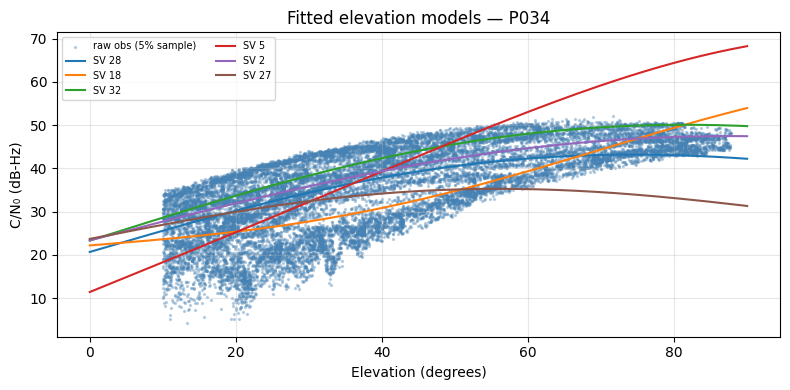

In [47]:
# Plot a few fitted models for the target station to verify they look sensible
target_svs = [
    sv for (st, sv) in sv_models
    if st == TARGET_STATION
][:6]   # up to 6 satellites

el_range = np.linspace(0, 90, 200)
fig, ax = plt.subplots(figsize=(8, 4))

# scatter raw data (thinned for speed)
raw = baseline_joined.filter(pl.col("station") == TARGET_STATION).sample(fraction=0.05, seed=0)
ax.scatter(raw["elevation"].to_numpy(), raw["snr"].to_numpy(),
           s=2, alpha=0.3, color="steelblue", label="raw obs (5% sample)")

for sv in target_svs:
    a, b, c = sv_models[(TARGET_STATION, sv)]
    ax.plot(el_range, elevation_model(el_range, a, b, c), lw=1.5, label=f"SV {sv}")

ax.set_xlabel("Elevation (degrees)")
ax.set_ylabel("C/N₀ (dB-Hz)")
ax.set_title(f"Fitted elevation models — {TARGET_STATION}")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Compute C/N₀ residuals

Now we apply the fitted models to the analysis period — the window we actually want to check for jamming.

For every observation in the analysis data we ask: *given where this satellite was in the sky at this moment, what C/N₀ would we normally expect?* The answer comes from plugging the satellite's elevation angle into the fitted curve. We then subtract that prediction from the measured value:

$$\text{residual} = \text{C/N}_0^{\text{observed}} - \text{C/N}_0^{\text{model}}(\varepsilon)$$

**What the residual tells you:**

- Near **zero** — the receiver is seeing what the model predicts; conditions are normal.
- **Positive** — the signal is unusually strong. This is rare but can occur with certain ionospheric conditions that focus signal energy.
- **Negative** — the signal is weaker than expected. Mild negative residuals (−1 to −2 dB-Hz) are normal noise. Large, simultaneous negative residuals across many satellites are the signature of jamming.

**Fallback model.** If a particular (station, satellite) pair has no fitted model — because that satellite wasn't visible enough during the baseline — we fall back to the average of all the other satellites' models for that station. This prevents those observations from being silently dropped while still using the best available estimate.

The result of this cell is a table with one row per observation, carrying both the raw C/N₀ and the residual. The detection steps that follow only use the residuals.

In [48]:
def compute_residuals(
    obs_df: pl.DataFrame,
    eph_df: pl.DataFrame,
    models: dict[tuple, np.ndarray],
    stations: list[str],
) -> pl.DataFrame:
    """
    Join analysis observations with ephemeris, then subtract the fitted
    model from each observation.  Returns the joined DataFrame with two
    extra columns: snr_expected and residual.
    """
    joined = join_obs_eph(obs_df, eph_df, stations)

    # Station-level fallback: mean of all fitted SV models for that station
    station_fallback: dict[str, np.ndarray] = {}
    for station in stations:
        params_list = [v for (st, _), v in models.items() if st == station]
        if params_list:
            station_fallback[station] = np.mean(params_list, axis=0)

    parts = []
    for (station, sv), sub in joined.group_by(["station", "satellite"]):
        sub = sub.drop_nulls(["snr", "elevation"])
        if len(sub) == 0:
            continue

        # Use explicit None checks — `or` on a numpy array raises ValueError
        params = models.get((station, sv))
        if params is None:
            params = station_fallback.get(station)
        if params is None:
            continue

        expected  = elevation_model(sub["elevation"].to_numpy(), *params)
        residuals = sub["snr"].to_numpy() - expected

        sub = sub.with_columns([
            pl.Series("snr_expected", expected.astype(np.float32)),
            pl.Series("residual",     residuals.astype(np.float32)),
        ])
        parts.append(sub)

    return pl.concat(parts).sort(["station", "timestamp"]) if parts else pl.DataFrame()


residuals_df = compute_residuals(analysis_obs, analysis_eph, sv_models, ALL_STATIONS)
print(f"Residuals computed: {len(residuals_df):,} rows")
residuals_df.select(["station", "timestamp", "satellite", "snr", "snr_expected", "residual"]).head(8)

Residuals computed: 142,606 rows


station,timestamp,satellite,snr,snr_expected,residual
str,"datetime[ms, UTC]",i8,f32,f32,f32
"""JFWS""",2019-01-20 00:00:00 UTC,27,42.400002,32.146496,10.253508
"""JFWS""",2019-01-20 00:00:00 UTC,23,26.5,25.145884,1.354117
"""JFWS""",2019-01-20 00:00:00 UTC,8,46.0,46.931522,-0.931521
"""JFWS""",2019-01-20 00:00:00 UTC,30,36.900002,39.28376,-2.383758
"""JFWS""",2019-01-20 00:00:00 UTC,11,31.200001,24.669607,6.530394
"""JFWS""",2019-01-20 00:00:00 UTC,7,47.099998,47.934738,-0.834741
"""JFWS""",2019-01-20 00:00:00 UTC,28,25.299999,32.168076,-6.868075
"""JFWS""",2019-01-20 00:00:00 UTC,9,39.099998,39.237377,-0.137378


## Step 7 — Epoch aggregation

At 30-second cadence with up to 10 satellites in view, we have up to 20 individual residual values per minute per station. Before running the detectors we collapse these into a single summary row per one-minute window (an *epoch*) using several statistics:

- **`mean_residual`** — the average residual across all visible satellites in the window. This is the primary detector input. Jamming suppresses all satellites together, so the mean responds strongly to a genuine event while averaging out single-satellite glitches.
- **`std_residual`** — the spread of the residuals. Under normal conditions this is roughly 1–2 dB-Hz. A sudden increase in spread (without a mean shift) can indicate unusual atmospheric conditions.
- **`min_residual`** — the most-suppressed satellite in the window. Useful for understanding the severity of the worst-affected link.
- **`n_svs`** — how many satellites contributed. The threshold detector requires this to be ≥ 3, which is the key guard against single-satellite events triggering a false alarm.
- **`mean_snr`** — the raw (un-residualised) C/N₀ average, useful as an absolute-level sanity check.

The one-minute bin width (`TIME_BIN = "1m"`) is a reasonable default. Narrower bins are more sensitive to fast jamming events but noisier; wider bins smooth out short bursts but respond more slowly.

In [49]:
def compute_epoch_anomaly(residuals_df: pl.DataFrame, time_bin: str = TIME_BIN) -> pl.DataFrame:
    """Aggregate per-observation residuals into per-epoch statistics."""
    return (
        residuals_df
        .with_columns(pl.col("timestamp").dt.truncate(time_bin).alias("epoch"))
        .group_by(["station", "epoch"])
        .agg([
            pl.col("residual").mean().alias("mean_residual"),
            pl.col("residual").std().alias("std_residual"),
            pl.col("residual").min().alias("min_residual"),
            pl.col("satellite").n_unique().alias("n_svs"),
            pl.col("snr").mean().alias("mean_snr"),
        ])
        .sort(["station", "epoch"])
    )


epoch_df = compute_epoch_anomaly(residuals_df)
print(f"Epoch table: {len(epoch_df):,} rows")
epoch_df.head(8)

Epoch table: 8,640 rows


station,epoch,mean_residual,std_residual,min_residual,n_svs,mean_snr
str,"datetime[ms, UTC]",f32,f32,f32,u32,f32
"""JFWS""",2019-01-20 00:00:00 UTC,1.028621,4.905422,-6.868075,8,36.962502
"""JFWS""",2019-01-20 00:01:00 UTC,0.845797,5.028749,-8.253249,8,36.756248
"""JFWS""",2019-01-20 00:02:00 UTC,0.888399,4.936009,-7.941019,8,36.775002
"""JFWS""",2019-01-20 00:03:00 UTC,0.981413,4.32269,-6.3342,8,36.84375
"""JFWS""",2019-01-20 00:04:00 UTC,0.84982,3.926092,-6.219135,8,36.6875
"""JFWS""",2019-01-20 00:05:00 UTC,0.456108,3.858629,-6.692985,8,36.268749
"""JFWS""",2019-01-20 00:06:00 UTC,0.181515,3.738459,-6.873173,8,35.96875
"""JFWS""",2019-01-20 00:07:00 UTC,0.351028,4.098322,-7.151448,8,36.112499


## Step 8 — Detectors

Two detectors run on the epoch table and complement each other. The threshold detector catches sharp, obvious events; the CUSUM detector catches slow-burn ones.

### Threshold detector

The rule is simple: **alarm if the epoch mean residual falls below −3 dB-Hz AND at least 3 satellites are in view.** Both conditions must be true simultaneously.

The −3 dB-Hz level is chosen to be about 1.5–2× the typical residual noise floor. Anything shallower is hard to distinguish from normal atmospheric variability. The satellite count requirement (`n_svs ≥ 3`) is a critical false-positive guard: if only one satellite drops, it could be a satellite anomaly, a momentary obstruction, or a data dropout. Only when three or more satellites drop together is the all-sky suppression pattern consistent with jamming.

### CUSUM detector

CUSUM (Cumulative Sum) is a classic statistical technique for detecting a *shift* in the mean of a signal. The downward-shift version used here is:

$$S(t) = \max\!\bigl(0,\; S(t-1) + (-r(t) - k)\bigr)$$

In plain terms: at each epoch, take the negative of the mean residual (so a more-negative residual becomes a more-positive contribution), subtract a slack `k`, and add it to a running total `S`. If conditions improve (residuals return to normal), the `max(0, …)` clamps `S` back to zero. If they stay degraded, `S` climbs. When `S` exceeds the alarm level `h`, the detector fires.

- **`k = 1.5` dB-Hz (slack)** — residuals smaller than 1.5 dB-Hz below zero are treated as noise and contribute nothing to `S`. This prevents a stream of mild −1 dB-Hz fluctuations from slowly accumulating into a false alarm.
- **`h = 5.0` (alarm threshold)** — roughly equivalent to requiring the mean residual to be suppressed by at least `k + h/n_epochs` dB-Hz on average over a sustained window. Increase `h` for fewer false alarms; decrease it for faster response to weak jammers.

The CUSUM detector catches scenarios the threshold detector misses: a jammer operating just below the −3 dB-Hz threshold that persists for many consecutive minutes will accumulate `S` until the alarm fires, even though no individual epoch was alarming on its own.

In [50]:
def apply_threshold_detector(
    epoch_df: pl.DataFrame,
    threshold_db: float = RESIDUAL_THRESHOLD_DB,
    min_svs: int = MIN_SVS_AFFECTED,
) -> pl.DataFrame:
    """Add boolean column 'threshold_alarm'."""
    return epoch_df.with_columns(
        (
            (pl.col("mean_residual") < threshold_db) &
            (pl.col("n_svs") >= min_svs)
        ).alias("threshold_alarm")
    )


def apply_cusum_detector(
    epoch_df: pl.DataFrame,
    k: float = CUSUM_K,
    h: float = CUSUM_H,
) -> pl.DataFrame:
    """Add columns 'cusum' and 'cusum_alarm' per station."""
    parts = []
    for station in epoch_df["station"].unique().to_list():
        sub  = epoch_df.filter(pl.col("station") == station).sort("epoch")
        vals = sub["mean_residual"].to_numpy()

        S = np.zeros(len(vals), dtype=np.float32)
        for i in range(1, len(vals)):
            S[i] = max(0.0, S[i - 1] + (-vals[i] - k))

        sub = sub.with_columns([
            pl.Series("cusum",       S),
            pl.Series("cusum_alarm", S > h),
        ])
        parts.append(sub)

    return pl.concat(parts) if parts else epoch_df


epoch_df = apply_threshold_detector(epoch_df)
epoch_df = apply_cusum_detector(epoch_df)

for station in ALL_STATIONS:
    sub = epoch_df.filter(pl.col("station") == station)
    n_thr  = sub["threshold_alarm"].sum()
    n_cusum = sub["cusum_alarm"].sum()
    print(f"{station}: {n_thr} threshold alarms, {n_cusum} CUSUM alarms")

P034: 31 threshold alarms, 239 CUSUM alarms
JFWS: 0 threshold alarms, 0 CUSUM alarms


## Step 9 — Results plot

Three time-series panels are produced for each station, sharing a common horizontal time axis so events line up visually.

**Panel 1 — Raw SNR.** Each dot is one observation from one satellite at one epoch. This gives an unfiltered view of the receiver's environment. Under normal operation the dots form a dense band whose upper and lower edges trace out the elevation-dependent envelope. A jamming event looks like the whole band dropping together — an obvious visual collapse.

**Panel 2 — Epoch mean residual.** This is the cleaned-up view. With the elevation dependence removed, the signal should hover near the zero line. The dashed red line marks the −3 dB-Hz threshold. Red shading marks epochs where the threshold detector fired. A genuine jamming event stands out clearly as a sustained excursion below the threshold that affects multiple epochs in a row; a single-satellite glitch would barely register because it gets averaged with all the other healthy satellites.

**Panel 3 — CUSUM statistic.** This panel shows the accumulated evidence for a sustained degradation. Under normal conditions `S` sits near zero or bounces back quickly. A flat-bottomed jammer that never breaks the threshold in Panel 2 will produce a steadily rising staircase here. The dashed red line marks the alarm level `h`; red shading marks CUSUM alarm epochs.

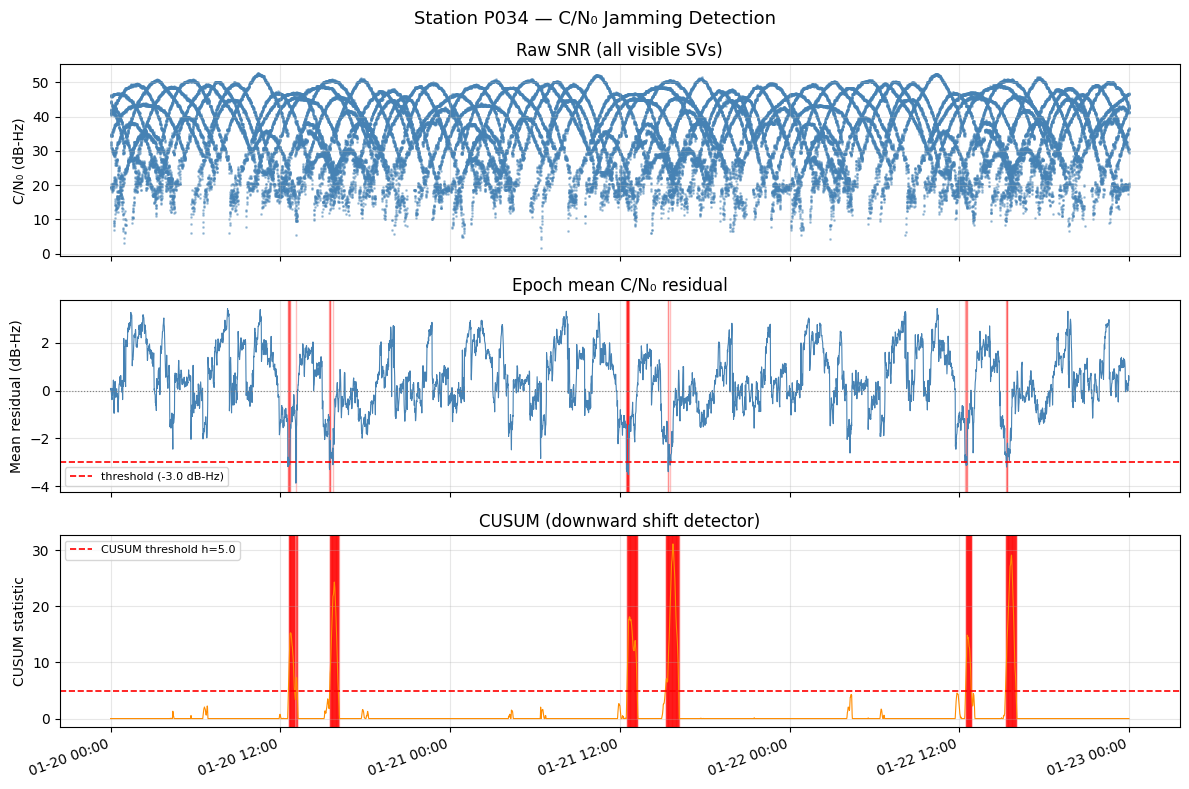

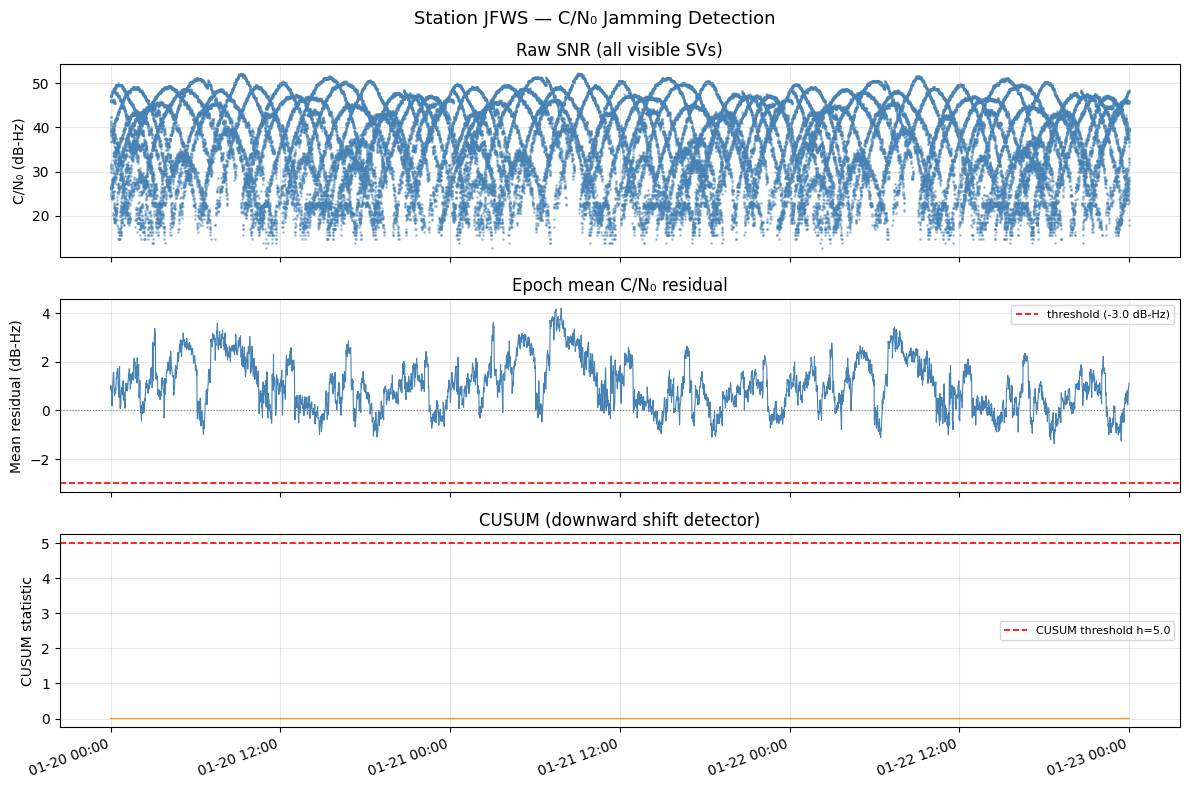

In [51]:
def plot_station_results(station: str, residuals_df: pl.DataFrame, epoch_df: pl.DataFrame):
    res_st   = residuals_df.filter(pl.col("station") == station)
    epoch_st = epoch_df.filter(pl.col("station") == station).sort("epoch")

    snr_raw  = res_st["snr"].to_numpy()
    mean_res = epoch_st["mean_residual"].to_numpy()
    cusum_vals  = epoch_st["cusum"].to_numpy()
    thr_alarm   = epoch_st["threshold_alarm"].to_numpy()
    cusum_alarm = epoch_st["cusum_alarm"].to_numpy()

    # Polars datetime columns → numpy datetime64 → matplotlib date numbers
    ts_dt    = mdates.date2num(res_st["timestamp"].to_numpy())
    epoch_dt = mdates.date2num(epoch_st["epoch"].to_numpy())

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Station {station} — C/N₀ Jamming Detection", fontsize=13)

    # Panel 1: raw SNR
    axes[0].scatter(ts_dt, snr_raw, s=1, alpha=0.4, color="steelblue")
    axes[0].set_ylabel("C/N₀ (dB-Hz)")
    axes[0].set_title("Raw SNR (all visible SVs)")
    axes[0].grid(True, alpha=0.3)

    # Panel 2: epoch mean residual + threshold alarms
    axes[1].plot(epoch_dt, mean_res, color="steelblue", lw=0.8)
    axes[1].axhline(RESIDUAL_THRESHOLD_DB, color="red", ls="--", lw=1.2,
                    label=f"threshold ({RESIDUAL_THRESHOLD_DB} dB-Hz)")
    axes[1].axhline(0, color="gray", ls=":", lw=0.8)
    for i, alarming in enumerate(thr_alarm):
        if alarming and i < len(epoch_dt):
            axes[1].axvspan(epoch_dt[i], epoch_dt[min(i + 1, len(epoch_dt) - 1)],
                            alpha=0.25, color="red")
    axes[1].set_ylabel("Mean residual (dB-Hz)")
    axes[1].set_title("Epoch mean C/N₀ residual")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # Panel 3: CUSUM
    axes[2].plot(epoch_dt, cusum_vals, color="darkorange", lw=0.8)
    axes[2].axhline(CUSUM_H, color="red", ls="--", lw=1.2,
                    label=f"CUSUM threshold h={CUSUM_H}")
    for i, alarming in enumerate(cusum_alarm):
        if alarming and i < len(epoch_dt):
            axes[2].axvspan(epoch_dt[i], epoch_dt[min(i + 1, len(epoch_dt) - 1)],
                            alpha=0.25, color="red")
    axes[2].set_ylabel("CUSUM statistic")
    axes[2].set_title("CUSUM (downward shift detector)")
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


for station in ALL_STATIONS:
    plot_station_results(station, residuals_df, epoch_df)

## Step 10 — Alarm summary and target vs. reference comparison

The first cell lists every epoch where either detector fired at any station, along with the key statistics: how many satellites were affected, how deep the mean residual went, and how high the CUSUM statistic climbed. This table is the primary output — you can export it, flag it for review, or feed it into a downstream alert system.

The second cell performs the local vs. regional discrimination. It compares the set of alarm epochs at the target station against those at the reference station:

- **Target-only alarms** — the target station sees degraded signal but the reference (hundreds of kilometres away) is clean. A jammer with a few kilometres of range cannot reach both simultaneously. This is strong evidence of a **local, ground-based jammer**.

- **Shared alarms** — both stations alarm around the same time. A ground-based jammer in one location cannot explain this unless both receivers happen to be jammed independently. More likely causes are a geomagnetic storm or ionospheric disturbance affecting a wide area, or a solar radio burst — all of which are regional or global in extent and unrelated to intentional interference.

Note that this two-station check is a simplified version of a full network analysis. Adding more target stations in a tight cluster and requiring at least two to alarm simultaneously (rather than just one) would further reduce false positives.

In [124]:
alarms = (
    epoch_df
    .filter(pl.col("threshold_alarm") | pl.col("cusum_alarm"))
    .select(["station", "epoch", "mean_residual", "n_svs", "cusum",
             "threshold_alarm", "cusum_alarm"])
    .sort(["epoch", "station"])
)

print(f"Total alarm epochs: {len(alarms)}")
alarms

Total alarm epochs: 3611


station,epoch,mean_residual,n_svs,cusum,threshold_alarm,cusum_alarm
str,"datetime[ms, UTC]",f32,u32,f32,bool,bool
"""P026""",2022-01-20 01:32:00 UTC,-2.060236,6,5.441639,false,true
"""P026""",2022-01-20 01:33:00 UTC,-1.53573,7,5.477369,false,true
"""P026""",2022-01-20 01:34:00 UTC,-1.716414,7,5.693784,false,true
"""P026""",2022-01-20 01:35:00 UTC,-1.360139,7,5.553923,false,true
"""P026""",2022-01-20 01:36:00 UTC,-1.159737,7,5.21366,false,true
"""P026""",2022-01-20 02:24:00 UTC,-2.249723,6,5.564494,false,true
"""P026""",2022-01-20 02:25:00 UTC,-2.34056,6,6.405054,false,true
"""P026""",2022-01-20 02:26:00 UTC,-2.305079,6,7.210133,false,true
"""P026""",2022-01-20 02:27:00 UTC,-2.43497,6,8.145103,false,true


In [125]:
# Which alarm epochs appear in the target but NOT the reference?
target_alarm_epochs = set(
    epoch_df
    .filter((pl.col("station") == TARGET_STATION) &
            (pl.col("threshold_alarm") | pl.col("cusum_alarm")))
    ["epoch"].to_list()
)

reference_alarm_epochs = set(
    epoch_df
    .filter((pl.col("station") == REFERENCE_STATION) &
            (pl.col("threshold_alarm") | pl.col("cusum_alarm")))
    ["epoch"].to_list()
)

local_only = target_alarm_epochs - reference_alarm_epochs
shared     = target_alarm_epochs & reference_alarm_epochs

print(f"Target-only alarm epochs (likely local jammer): {len(local_only)}")
print(f"Shared alarm epochs (possible regional/space weather): {len(shared)}")

Target-only alarm epochs (likely local jammer): 2782
Shared alarm epochs (possible regional/space weather): 382


## Step 11 — Interpretation guide and next steps

### Reading the results

| What you observe | Most likely explanation |
|---|---|
| Target alarms, reference is clean | Local ground-based jammer within ~5 km of the target station |
| Both stations alarm at the same time | Regional space weather event (geomagnetic storm, solar radio burst) or widespread ionospheric disturbance |
| Very deep residual on one satellite only (`n_svs = 1`) | That satellite had an anomaly, was briefly obstructed, or experienced a data dropout |
| CUSUM rises slowly but threshold never fires | Low-power persistent jammer operating just below the threshold — the most insidious type |
| Alarm lasts only 1–2 epochs then disappears | Short burst — possibly a vehicle-mounted jammer driving past, or a brief keying of a transmitter |
| Residuals consistently positive for one satellite | That satellite's transmit power may have changed since the baseline; consider re-fitting the model |

### Limitations of this simplified notebook

- **No terrain masking.** Near steep hills or buildings, satellites close to the local horizon are partially blocked and their SNR drops sharply in a way the elevation model cannot predict. These can cause false alarms at low elevation. The full pipeline includes a DEM-based horizon mask to remove them.
- **Single target station.** With only one target it is impossible to confirm that the degradation is spatially localised. A genuine local jammer would affect a tight cluster of stations simultaneously; requiring two or more to alarm is a much stronger test.
- **GPS L1 only.** Consumer jammers overwhelmingly target L1 because that is the frequency used by cheap vehicle trackers. But some jammers broadcast across a wider band. Fetching L2 observations (`obs_code="2W"`) and checking whether L1 and L2 drop together (broadband jammer) or independently (ionospheric scintillation, which is frequency-dispersive) provides a powerful additional discriminator.
- **Fixed thresholds.** The −3 dB-Hz threshold and CUSUM parameters are reasonable starting points but are not tuned to this specific receiver or environment. A principled approach is to compute the standard deviation σ of the baseline residuals for each station and set `RESIDUAL_THRESHOLD_DB = −3σ` and `CUSUM_K = 1σ`.

### Where to go next

If you want to extend this notebook into a more complete detection system, the modules in the `gnss_jamming/` package in this repository implement all of the above enhancements: terrain masking via USGS DEMs, multi-station network correlation, multi-frequency comparison, and an event summary table with discrimination scores.